<a href="https://colab.research.google.com/github/yunayana/Sztuczna_Inteligancja_STAC_2026/blob/main/Lab1_Model_liniowy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [4]:
observations=1000000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000000, 2)


In [5]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13 * xs + 7 * zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000000, 1)


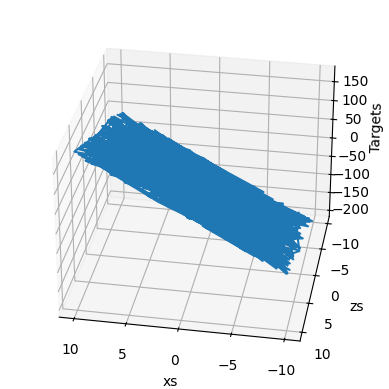

In [6]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs[::1000], zs[::1000], targets[::1000])
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [7]:

init_range= 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[-0.02575842]
 [-0.0207161 ]] [0.04518265]


In [11]:
targets = targets.reshape(observations, 1)
eta = 0.001
for i in range (1000):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

63.651984424681515
63.26480442912746
62.89550223392951
62.54291812414122
62.20596856521315
61.88364119686028
61.57499015590668
61.279131706489416
60.99524015742369
60.7225440478579
60.460322583588585
60.20790230756218
59.96465398917532
59.72998971799432
59.5033601884603
59.28425216303053
59.07218610202884
58.8667139492503
58.667417063084656
58.473904283596355
58.28581012662532
58.102793096563246
57.92453411000485
57.75073502298932
57.581117255023514
57.41542050352767
57.253401542760855
57.09483310167499
56.93950281551089
56.787212246289414
56.63777596767138
56.49102070995554
56.34678456126299
56.20491622121554
56.065274303658306
55.92772668520433
55.79214989658873
55.65842855402018
55.526454827901404
55.3961279464615
55.267353732008345
55.140044167654864
55.01411699251832
54.88949532352076
54.76610730204301
54.64388576379815
54.52276793039975
54.402695121197915
54.28361248405248
54.165468743798115
54.04821596723861
53.931809343585094
53.816206979321876
53.70136970655331
53.587260903944

In [12]:
print(weights, biases)

[[12.99971421]
 [ 7.00019703]] [-7.99243485]


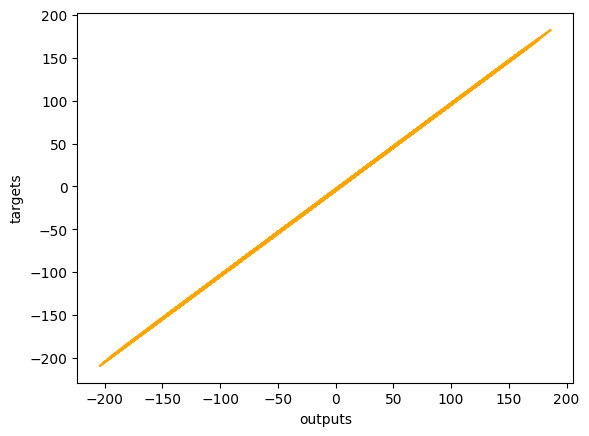

In [13]:
plt.plot(outputs.flatten()[::1000], targets.flatten()[::1000], color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()